# <div align="right"><span style="color:lightgrey">Université Paul Sabatier - 2025 - Projet</span></div>

# Projet : TER


---
- **Diallo Moussa**
- **Guy-Alexandre**
- **Mariam Boumejhoul**
---


---
### $$\text{Projet  : Visualisation d'un réseau de neurones }$$


Il s'agit de produire un petit logiciel de visualisation (en python) qui permet d'illustrer de façon claire et intelligible les transformations des données effectuées par un réseau de neurone pour arriver à un résultat (ou une classification)



---

<br><br>

<font color="blue ">On commence par  installer puis importer les bibliothèques necessaire pour tout le document :</font>


In [ ]:
!pip install tensorflow matplotlib pillow

<br><br>


<h1 style="color:blue; font-size:32px;">
CHAPITRE 1: FONDEMENTS THÉORIQUES
</h1>



In [ ]:
import numpy as np
#%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.core.debugger import set_trace
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
import tensorflow as tf
from PIL import Image
from google.colab import files
from sklearn import datasets
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape, Input
from tensorflow.keras.models import Model


=== Fonction Sigmoïde ===
σ(z) = 1 / (1 + e^(-z))
Propriétés :
- Sortie dans l'intervalle (0, 1)
- Dérivée : σ'(z) = σ(z)(1 - σ(z))
- Problème : gradient qui disparaît

=== Fonction ReLU ===
ReLU(z) = max(0, z)
Propriétés :
- Simple à calculer
- Dérivée : 1 si z > 0, 0 sinon
- Résout partiellement le problème du gradient disparu

=== Fonction Tanh ===
tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))
Propriétés :
- Sortie dans (-1, 1)
- Centrée autour de zéro


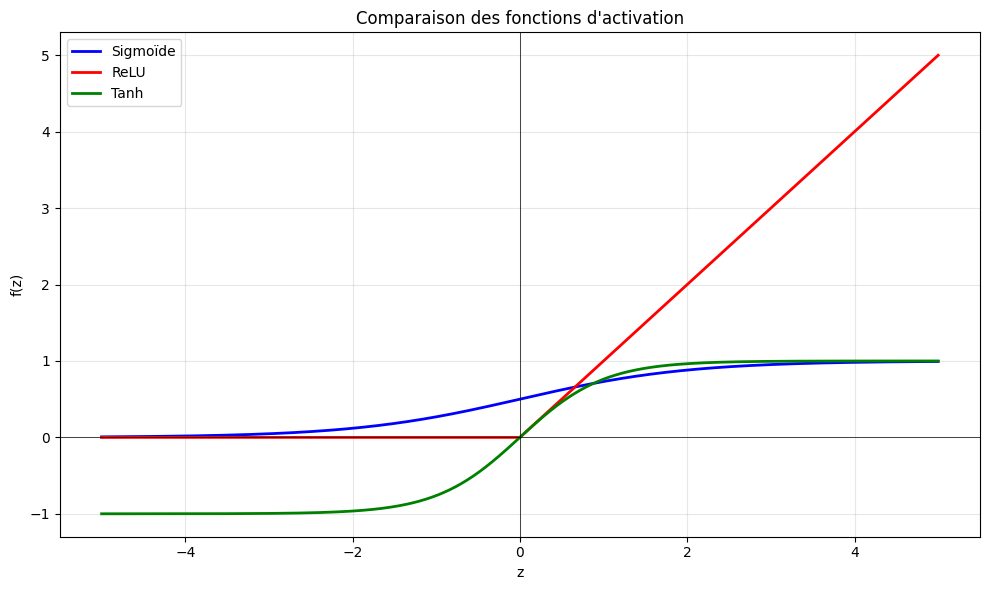

In [ ]:
# Activation functions and visualization in Python
import numpy as np
import matplotlib.pyplot as plt

# Définition des fonctions d'activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

# Texte explicatif simulant les sous-sections LaTeX
def afficher_description():
    print("=== Fonction Sigmoïde ===")
    print("σ(z) = 1 / (1 + e^(-z))")
    print("Propriétés :")
    print("- Sortie dans l'intervalle (0, 1)")
    print("- Dérivée : σ'(z) = σ(z)(1 - σ(z))")
    print("- Problème : gradient qui disparaît\n")

    print("=== Fonction ReLU ===")
    print("ReLU(z) = max(0, z)")
    print("Propriétés :")
    print("- Simple à calculer")
    print("- Dérivée : 1 si z > 0, 0 sinon")
    print("- Résout partiellement le problème du gradient disparu\n")

    print("=== Fonction Tanh ===")
    print("tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))")
    print("Propriétés :")
    print("- Sortie dans (-1, 1)")
    print("- Centrée autour de zéro")

# Visualisation
def tracer_fonctions_activation():
    z = np.linspace(-5, 5, 1000)

    plt.figure(figsize=(10, 6))
    plt.plot(z, sigmoid(z), label="Sigmoïde", color='blue', linewidth=2)
    plt.plot(z, relu(z), label="ReLU", color='red', linewidth=2)
    plt.plot(z, tanh(z), label="Tanh", color='green', linewidth=2)

    plt.title("Comparaison des fonctions d'activation")
    plt.xlabel("z")
    plt.ylabel("f(z)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Appel des fonctions
afficher_description()
tracer_fonctions_activation()


<br><br>


<h1 style="color:blue; font-size:32px;">
CHAPITRE 1: LE PERCEPTRON SIMPLE
</h1>


Implémentation du Perceptron Simple
    
    Théorie:
    Le perceptron est un modèle de neurone artificiel qui effectue une
    combinaison linéaire de ses entrées: ŷ = w^T x + b
    
    Pour la classification binaire: sortie = sign(w^T x + b)
    
    Algorithme d'apprentissage:
    1. Initialiser w = 0
    2. Pour chaque exemple mal classé:
       w ← w + y * x (où y ∈ {-1, +1})
    3. Répéter jusqu'à convergence
    """

In [ ]:
class Perceptron:


    def __init__(self, add_bias=True, max_iters=10000, record_updates=False):
        self.max_iters = max_iters
        self.add_bias = add_bias
        self.record_updates = record_updates
        if record_updates:
            self.w_hist = []  # enregistre les poids
            self.n_hist = []  # enregistre l'indice du point de données sélectionné

    def fit(self, x, y):
        if x.ndim == 1:
            x = x[:, None]
        if self.add_bias:
            N = x.shape[0]
            x = np.column_stack([x, np.ones(N)])  # ajout d'un biais (colonne de 1)
        N, D = x.shape
        w = np.zeros(D)  # initialisation des poids à zéro
        if self.record_updates:
            w_hist = [w]
        # y = np.sign(y - .1)  # pour obtenir +1 pour la classe 1 et -1 pour la classe 0
        y = 2 * y - 1  # conversion de 0,1 vers -1,+1
        t = 0
        change = True  # si les poids ne changent plus, l'algorithme a convergé
        while change and t < self.max_iters:
            change = False
            for n in np.random.permutation(N):
                yh = np.sign(np.dot(x[n, :], w))  # prédiction du point d'entraînement
                if yh == y[n]:
                    continue  # on ignore les points bien classés
                # w = w + (y[n] - yh) * x[n, :]  # mise à jour des poids
                w = w + y[n] * x[n, :]
                if self.record_updates:
                    self.w_hist.append(w)
                    self.n_hist.append(n)
                change = True
                t += 1
                if t >= self.max_iters:
                    break
        if change:
            print(f'pas convergé après {t} mises à jour')
        else:
            print(f'convergence après {t} itérations !')
        self.w = w
        return self

    def predict(self, x):
        if x.ndim == 1:
            x = x[:, None]
        Nt = x.shape[0]
        if self.add_bias:
            x = np.column_stack([x, np.ones(Nt)])  # ajout du biais si demandé
        yh = np.sign(np.dot(self.w, x))
        return (yh + 1) // 2  # conversion de -1/+1 vers les classes 0/1


Convergence de l’Algorithme Perceptron

Génération de convergence_separable.png...
Perceptron convergé en 14 mises à jour


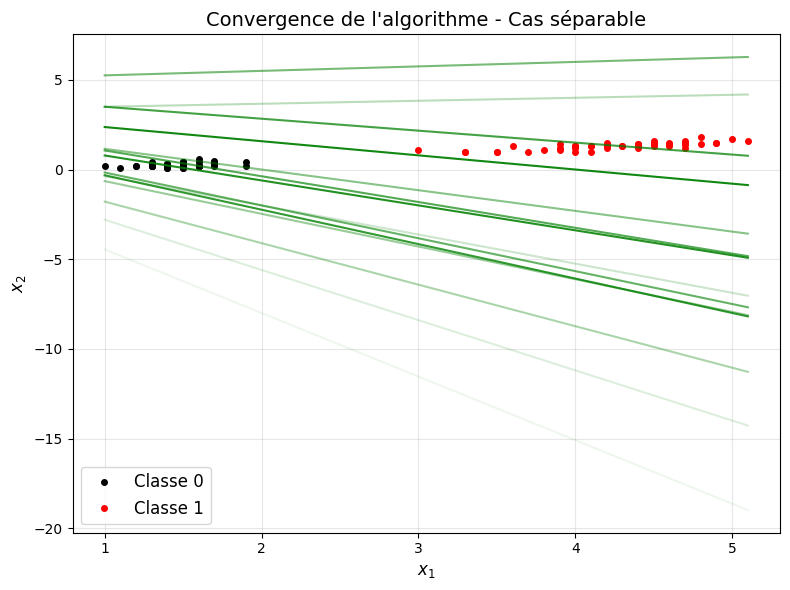

Cas séparable - Nombre de mises à jour: 15

Génération de convergence_non_separable.png...
Attention : Perceptron non convergé après 10000 mises à jour


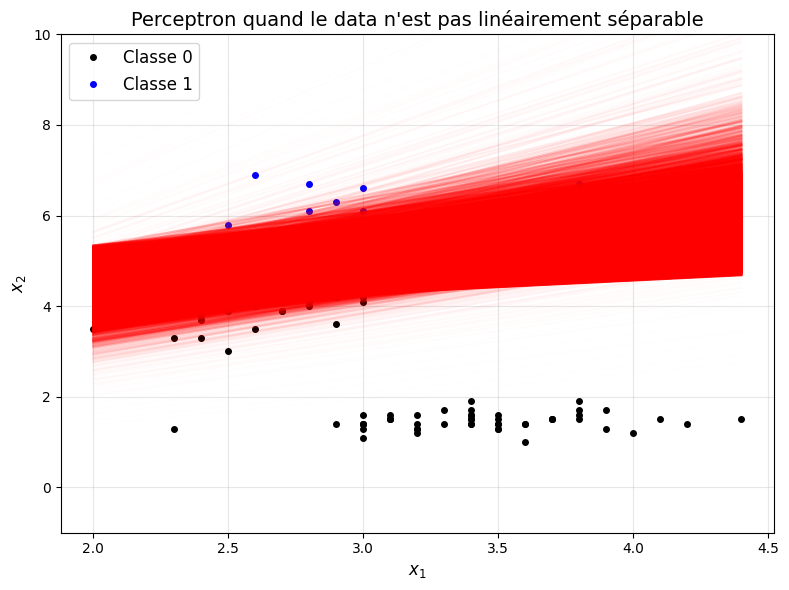

Cas non séparable - Nombre de mises à jour: 10001

Génération de la figure de comparaison...
Perceptron convergé en 3 mises à jour
Attention : Perceptron non convergé après 10000 mises à jour


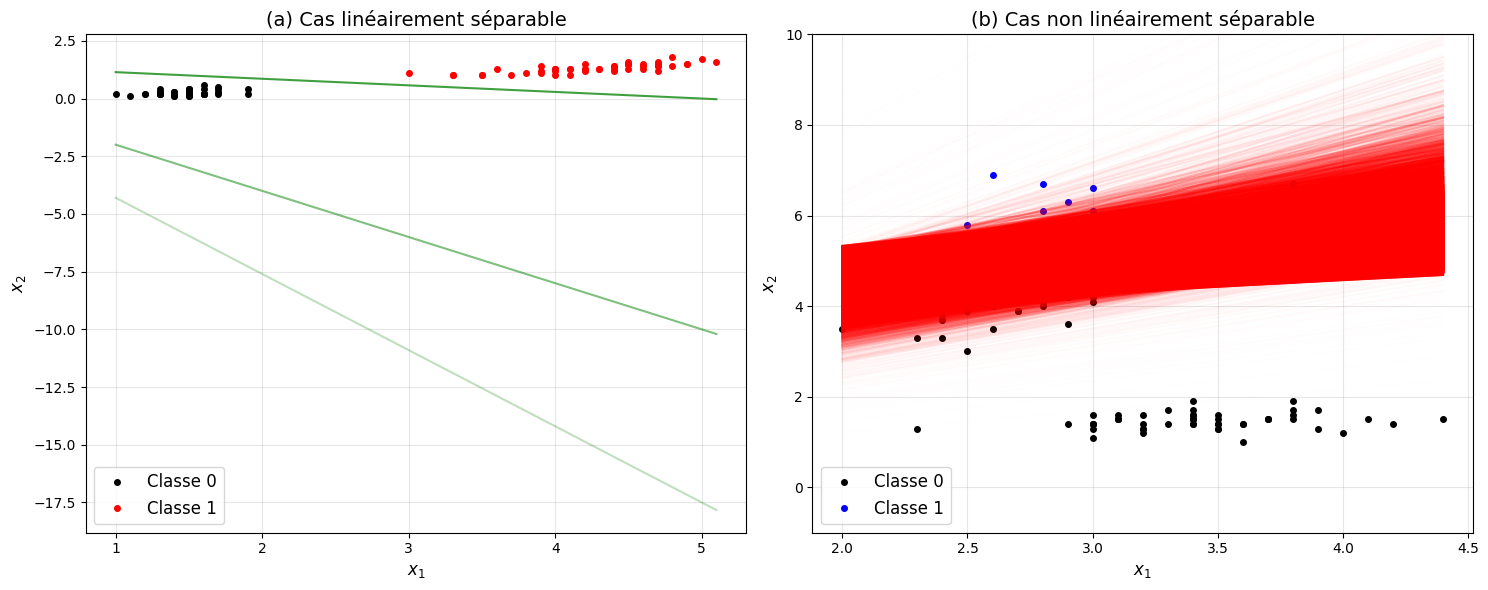

Comparaison - Séparable: 4 mises à jour
Comparaison - Non séparable: 10001 mises à jour
Génération de convergence_separable.png...
Perceptron convergé en 7 mises à jour


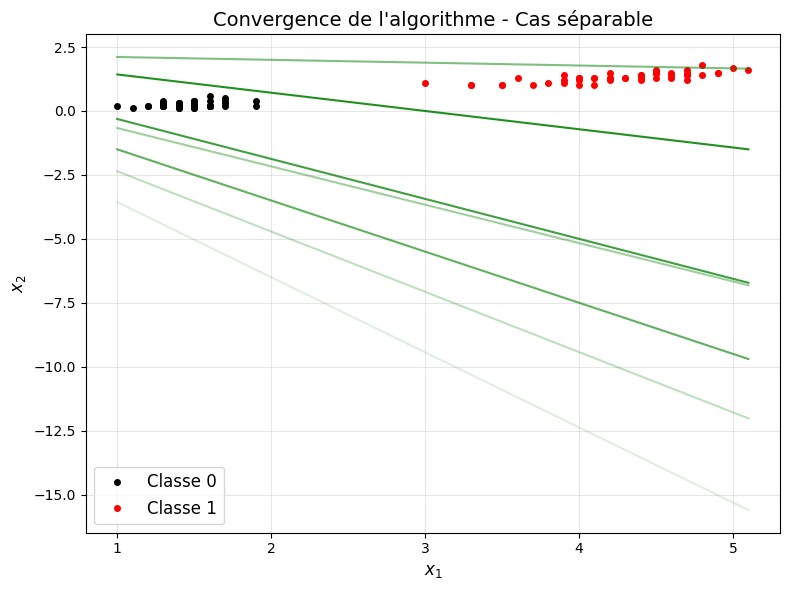

Cas séparable - Nombre de mises à jour: 8

Génération de convergence_non_separable.png...
Attention : Perceptron non convergé après 10000 mises à jour


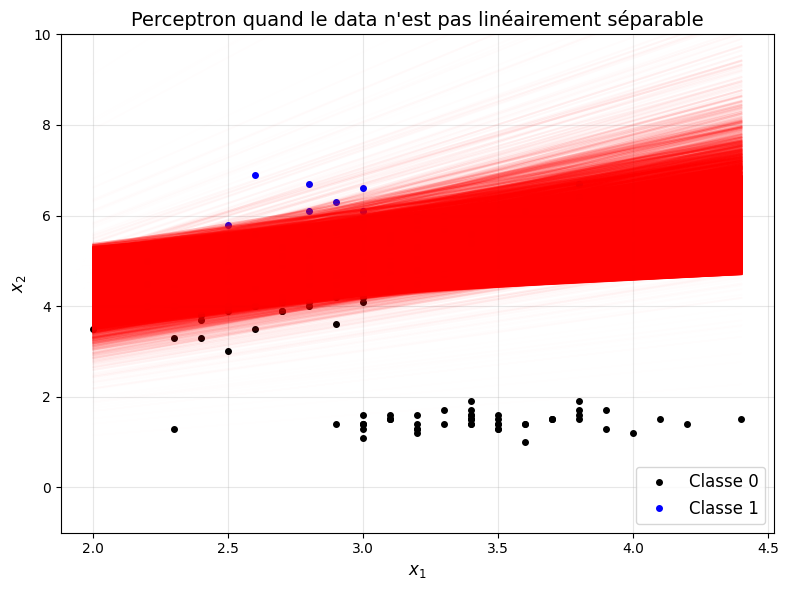

Cas non séparable - Nombre de mises à jour: 10001

Génération de la figure de comparaison...
Perceptron convergé en 16 mises à jour
Attention : Perceptron non convergé après 10000 mises à jour


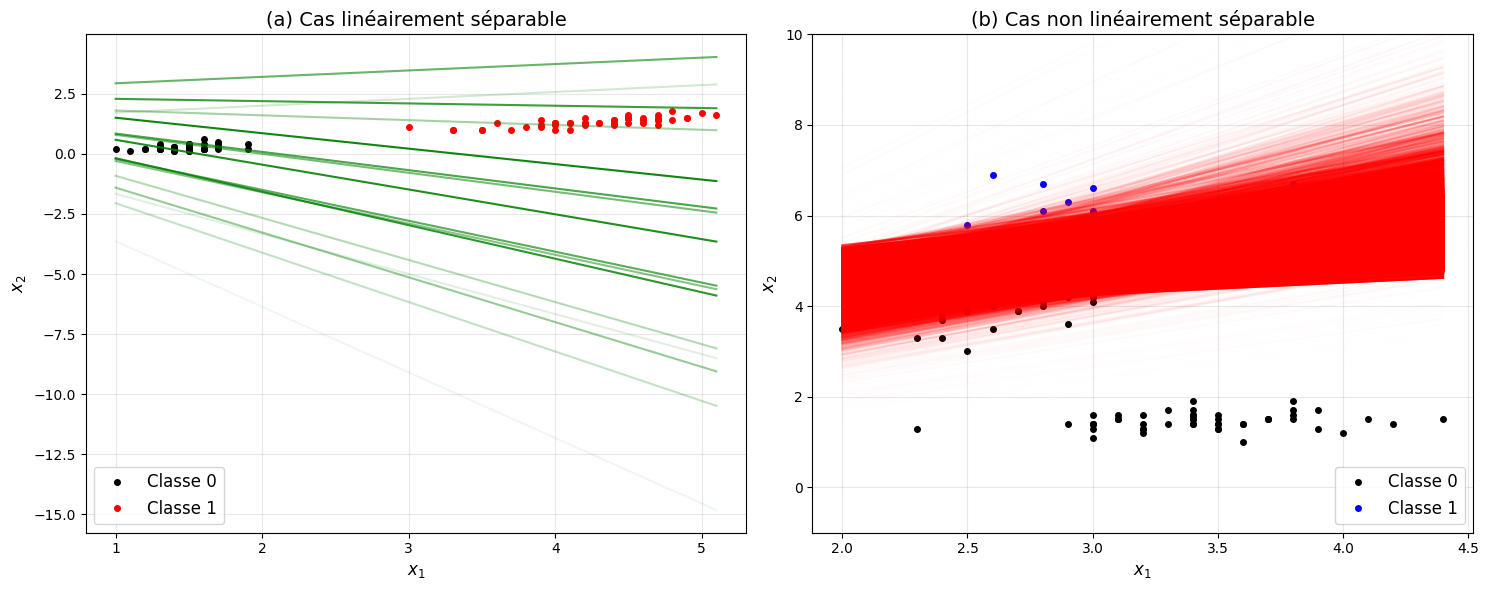

Comparaison - Séparable: 17 mises à jour
Comparaison - Non séparable: 10001 mises à jour


In [ ]:
# Code pour générer convergence_separable.png
def generate_convergence_separable():
    # Chargement du dataset Iris (2 classes, 2 features)
    dataset = datasets.load_iris()
    x, y = dataset['data'][:, 2:], dataset['target']  # les 2 dernières features
    x, y = x[y < 2, :], y[y < 2]  # classes 0 et 1 uniquement

    # On suppose que ta classe Perceptron s'appelle bien Perceptron et possède w_hist
    model = Perceptron(record_updates=True)
    model.fit(x, y)

    # Tracé des données avec couleurs modifiées
    plt.figure(figsize=(8, 6))
    plt.plot(x[y == 0, 0], x[y == 0, 1], 'k.', markersize=8, label='Classe 0')  # points classe 0 en noir
    plt.plot(x[y == 1, 0], x[y == 1, 1], 'r.', markersize=8, label='Classe 1')  # points classe 1 en rouge

    x_line = np.linspace(np.min(x[:, 0]), np.max(x[:, 0]), 100)

    # Tracé de la frontière en vert, alpha variant
    for t, w in enumerate(model.w_hist):
        coef = -w[0] / w[1]  # pente
        intercept = -w[2] / w[1]  # intercept
        plt.plot(x_line, coef * x_line + intercept, color='green',
                 alpha=t / len(model.w_hist), linewidth=1.5)

    plt.xlabel(r'$x_1$', fontsize=12)
    plt.ylabel(r'$x_2$', fontsize=12)
    plt.title('Convergence de l\'algorithme - Cas séparable', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Sauvegarder la figure
    plt.savefig('convergence_separable.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Cas séparable - Nombre de mises à jour: {len(model.w_hist)}")


# Code pour générer convergence_non_separable.png
def generate_convergence_non_separable():
    # Chargement du dataset Iris avec features différentes
    dataset = datasets.load_iris()
    x, y = dataset['data'][:,[1,2]], dataset['target']  # slice feature 1 and 2 of Iris dataset
    y = y > 1

    model = Perceptron(record_updates=True)
    yh = model.fit(x, y)

    plt.figure(figsize=(8, 6))
    plt.plot(x[y==0,0], x[y==0,1], 'k.', markersize=8, label='Classe 0')
    plt.plot(x[y==1,0], x[y==1,1], 'b.', markersize=8, label='Classe 1')

    x_line = np.linspace(np.min(x[:,0]), np.max(x[:,0]), 100)
    for t,w in enumerate(model.w_hist):
        coef = -w[0]/w[1]
        plt.plot(x_line, coef*x_line - w[2]/w[1], 'r-', alpha=t/len(model.w_hist), linewidth=1.5)

    plt.xlabel(r'$x_1$', fontsize=12)
    plt.ylabel(r'$x_2$', fontsize=12)
    plt.ylim(-1,10)
    plt.title('Perceptron quand le data n\'est pas linéairement séparable', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Sauvegarder la figure
    plt.savefig('convergence_non_separable.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Cas non séparable - Nombre de mises à jour: {len(model.w_hist)}")


# Code pour générer les deux figures côte à côte (optionnel)
def generate_comparison_figure():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Cas séparable
    dataset = datasets.load_iris()
    x1, y1 = dataset['data'][:, 2:], dataset['target']
    x1, y1 = x1[y1 < 2, :], y1[y1 < 2]

    model1 = Perceptron(record_updates=True)
    model1.fit(x1, y1)

    ax1.plot(x1[y1 == 0, 0], x1[y1 == 0, 1], 'k.', markersize=8, label='Classe 0')
    ax1.plot(x1[y1 == 1, 0], x1[y1 == 1, 1], 'r.', markersize=8, label='Classe 1')

    x_line1 = np.linspace(np.min(x1[:, 0]), np.max(x1[:, 0]), 100)
    for t, w in enumerate(model1.w_hist):
        coef = -w[0] / w[1]
        intercept = -w[2] / w[1]
        ax1.plot(x_line1, coef * x_line1 + intercept, color='green',
                alpha=t / len(model1.w_hist), linewidth=1.5)

    ax1.set_xlabel(r'$x_1$', fontsize=12)
    ax1.set_ylabel(r'$x_2$', fontsize=12)
    ax1.set_title('(a) Cas linéairement séparable', fontsize=14)
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)

    # Cas non séparable
    x2, y2 = dataset['data'][:,[1,2]], dataset['target']
    y2 = y2 > 1

    model2 = Perceptron(record_updates=True)
    model2.fit(x2, y2)

    ax2.plot(x2[y2==0,0], x2[y2==0,1], 'k.', markersize=8, label='Classe 0')
    ax2.plot(x2[y2==1,0], x2[y2==1,1], 'b.', markersize=8, label='Classe 1')

    x_line2 = np.linspace(np.min(x2[:,0]), np.max(x2[:,0]), 100)
    for t,w in enumerate(model2.w_hist):
        coef = -w[0]/w[1]
        ax2.plot(x_line2, coef*x_line2 - w[2]/w[1], 'r-', alpha=t/len(model2.w_hist), linewidth=1.5)

    ax2.set_xlabel(r'$x_1$', fontsize=12)
    ax2.set_ylabel(r'$x_2$', fontsize=12)
    ax2.set_ylim(-1,10)
    ax2.set_title('(b) Cas non linéairement séparable', fontsize=14)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('perceptron_comparaison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Comparaison - Séparable: {len(model1.w_hist)} mises à jour")
    print(f"Comparaison - Non séparable: {len(model2.w_hist)} mises à jour")


# Exécution des fonctions
if __name__ == "__main__":
    # Générer la figure du cas séparable
    print("Génération de convergence_separable.png...")
    generate_convergence_separable()

    # Générer la figure du cas non séparable
    print("\nGénération de convergence_non_separable.png...")
    generate_convergence_non_separable()

    # Optionnel: générer la figure de comparaison
    print("\nGénération de la figure de comparaison...")
    generate_comparison_figure()

# Code pour générer convergence_separable.png
def generate_convergence_separable():
    # Chargement du dataset Iris (2 classes, 2 features)
    dataset = datasets.load_iris()
    x, y = dataset['data'][:, 2:], dataset['target']  # les 2 dernières features
    x, y = x[y < 2, :], y[y < 2]  # classes 0 et 1 uniquement

    # On suppose que ta classe Perceptron s'appelle bien Perceptron et possède w_hist
    model = Perceptron(record_updates=True)
    model.fit(x, y)

    # Tracé des données avec couleurs modifiées
    plt.figure(figsize=(8, 6))
    plt.plot(x[y == 0, 0], x[y == 0, 1], 'k.', markersize=8, label='Classe 0')  # points classe 0 en noir
    plt.plot(x[y == 1, 0], x[y == 1, 1], 'r.', markersize=8, label='Classe 1')  # points classe 1 en rouge

    x_line = np.linspace(np.min(x[:, 0]), np.max(x[:, 0]), 100)

    # Tracé de la frontière en vert, alpha variant
    for t, w in enumerate(model.w_hist):
        coef = -w[0] / w[1]  # pente
        intercept = -w[2] / w[1]  # intercept
        plt.plot(x_line, coef * x_line + intercept, color='green',
                 alpha=t / len(model.w_hist), linewidth=1.5)

    plt.xlabel(r'$x_1$', fontsize=12)
    plt.ylabel(r'$x_2$', fontsize=12)
    plt.title('Convergence de l\'algorithme - Cas séparable', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Sauvegarder la figure
    plt.savefig('convergence_separable.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Cas séparable - Nombre de mises à jour: {len(model.w_hist)}")


# Code pour générer convergence_non_separable.png
def generate_convergence_non_separable():
    # Chargement du dataset Iris avec features différentes
    dataset = datasets.load_iris()
    x, y = dataset['data'][:,[1,2]], dataset['target']  # slice feature 1 and 2 of Iris dataset
    y = y > 1

    model = Perceptron(record_updates=True)
    yh = model.fit(x, y)

    plt.figure(figsize=(8, 6))
    plt.plot(x[y==0,0], x[y==0,1], 'k.', markersize=8, label='Classe 0')
    plt.plot(x[y==1,0], x[y==1,1], 'b.', markersize=8, label='Classe 1')

    x_line = np.linspace(np.min(x[:,0]), np.max(x[:,0]), 100)
    for t,w in enumerate(model.w_hist):
        coef = -w[0]/w[1]
        plt.plot(x_line, coef*x_line - w[2]/w[1], 'r-', alpha=t/len(model.w_hist), linewidth=1.5)

    plt.xlabel(r'$x_1$', fontsize=12)
    plt.ylabel(r'$x_2$', fontsize=12)
    plt.ylim(-1,10)
    plt.title('Perceptron quand le data n\'est pas linéairement séparable', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Sauvegarder la figure
    plt.savefig('convergence_non_separable.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Cas non séparable - Nombre de mises à jour: {len(model.w_hist)}")


# Code pour générer les deux figures côte à côte (optionnel)
def generate_comparison_figure():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Cas séparable
    dataset = datasets.load_iris()
    x1, y1 = dataset['data'][:, 2:], dataset['target']
    x1, y1 = x1[y1 < 2, :], y1[y1 < 2]

    model1 = Perceptron(record_updates=True)
    model1.fit(x1, y1)

    ax1.plot(x1[y1 == 0, 0], x1[y1 == 0, 1], 'k.', markersize=8, label='Classe 0')
    ax1.plot(x1[y1 == 1, 0], x1[y1 == 1, 1], 'r.', markersize=8, label='Classe 1')

    x_line1 = np.linspace(np.min(x1[:, 0]), np.max(x1[:, 0]), 100)
    for t, w in enumerate(model1.w_hist):
        coef = -w[0] / w[1]
        intercept = -w[2] / w[1]
        ax1.plot(x_line1, coef * x_line1 + intercept, color='green',
                alpha=t / len(model1.w_hist), linewidth=1.5)

    ax1.set_xlabel(r'$x_1$', fontsize=12)
    ax1.set_ylabel(r'$x_2$', fontsize=12)
    ax1.set_title('(a) Cas linéairement séparable', fontsize=14)
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)

    # Cas non séparable
    x2, y2 = dataset['data'][:,[1,2]], dataset['target']
    y2 = y2 > 1

    model2 = Perceptron(record_updates=True)
    model2.fit(x2, y2)

    ax2.plot(x2[y2==0,0], x2[y2==0,1], 'k.', markersize=8, label='Classe 0')
    ax2.plot(x2[y2==1,0], x2[y2==1,1], 'b.', markersize=8, label='Classe 1')

    x_line2 = np.linspace(np.min(x2[:,0]), np.max(x2[:,0]), 100)
    for t,w in enumerate(model2.w_hist):
        coef = -w[0]/w[1]
        ax2.plot(x_line2, coef*x_line2 - w[2]/w[1], 'r-', alpha=t/len(model2.w_hist), linewidth=1.5)

    ax2.set_xlabel(r'$x_1$', fontsize=12)
    ax2.set_ylabel(r'$x_2$', fontsize=12)
    ax2.set_ylim(-1,10)
    ax2.set_title('(b) Cas non linéairement séparable', fontsize=14)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('perceptron_comparaison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Comparaison - Séparable: {len(model1.w_hist)} mises à jour")
    print(f"Comparaison - Non séparable: {len(model2.w_hist)} mises à jour")


# Exécution des fonctions
if __name__ == "__main__":
    # Générer la figure du cas séparable
    print("Génération de convergence_separable.png...")
    generate_convergence_separable()

    # Générer la figure du cas non séparable
    print("\nGénération de convergence_non_separable.png...")
    generate_convergence_non_separable()

    # Optionnel: générer la figure de comparaison
    print("\nGénération de la figure de comparaison...")
    generate_comparison_figure()

Analyse quantitative de la convergence

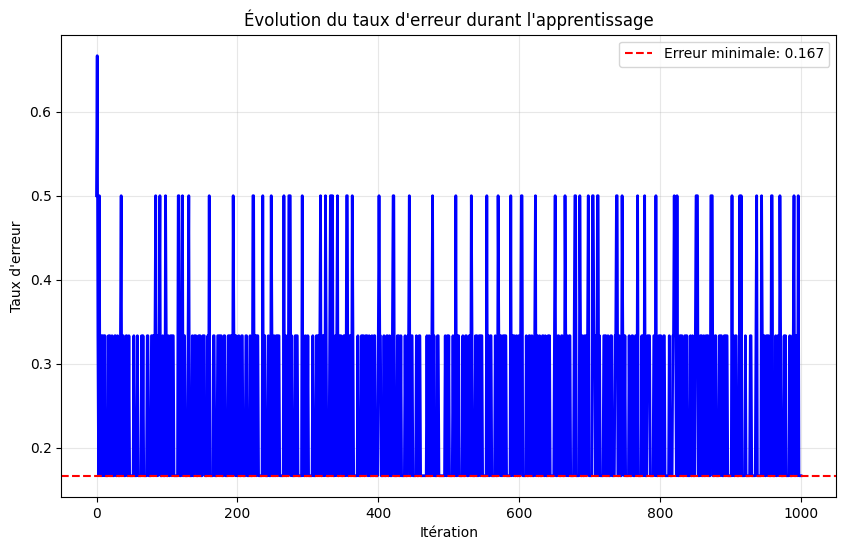

Nombre total de mises à jour: 1001
Erreur finale: 0.167
Erreur minimale atteinte: 0.167


In [ ]:
# Calcul de l'erreur de classification à chaque mise à jour
errors = []
for i, w in enumerate(model.w_hist):
    # Prédictions avec les poids actuels
    predictions = np.sign(np.dot(x, w[:-1]) + w[-1])
    predictions = (predictions + 1) // 2  # Conversion -1/+1 vers 0/1

    # Calcul de l'erreur
    error_rate = np.mean(predictions != y)
    errors.append(error_rate)

# Tracé de l'évolution de l'erreur
plt.figure(figsize=(10, 6))
plt.plot(errors, 'b-', linewidth=2)
plt.xlabel('Itération')
plt.ylabel('Taux d\'erreur')
plt.title('Évolution du taux d\'erreur durant l\'apprentissage')
plt.grid(True, alpha=0.3)
plt.axhline(y=min(errors), color='r', linestyle='--',
            label=f'Erreur minimale: {min(errors):.3f}')
plt.legend()
plt.show()

print(f"Nombre total de mises à jour: {len(model.w_hist)}")
print(f"Erreur finale: {errors[-1]:.3f}")
print(f"Erreur minimale atteinte: {min(errors):.3f}")

<br><br>


<h1 style="color:blue; font-size:32px;">
CHAPITRE 3: RÉSEAUX MULTICOUCHES (MLP)
</h1>


 """
    Visualisation des réseaux de neurones multicouches
    
    Théorie:
    Un MLP est composé de:
    1. Couche d'entrée: reçoit les données
    2. Couches cachées: traitement principal
    3. Couche de sortie: résultat final
    
    Chaque couche effectue: z = W*x + b, puis a = f(z)
    """

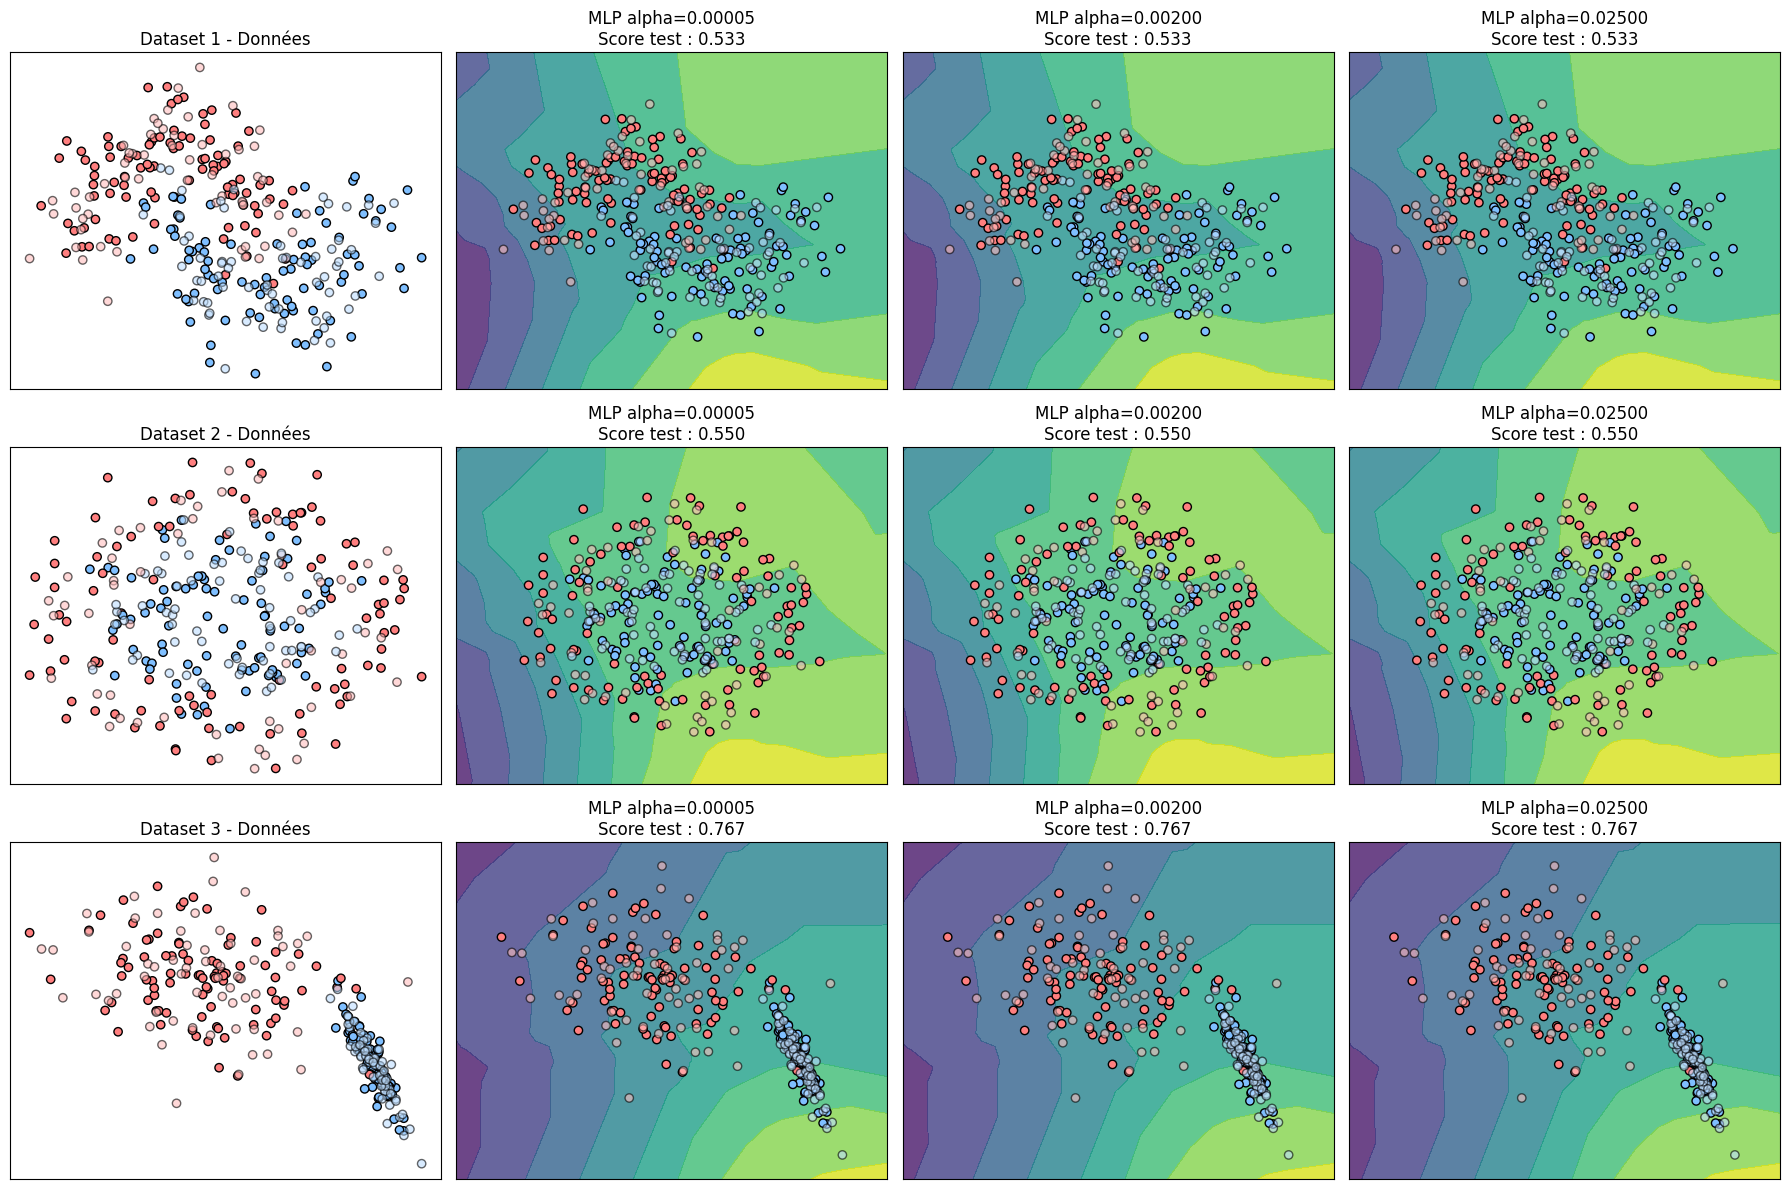

In [ ]:
# Création des datasets synthétiques variés
datasets = [
    make_moons(n_samples=300, noise=0.25, random_state=42),
    make_circles(n_samples=300, noise=0.2, factor=0.5, random_state=24),
    make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                        n_clusters_per_class=1, random_state=7)
]

alphas = [5e-5, 2e-3, 2.5e-2]
classifiers = []
names = []

for alpha in alphas:
    clf = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(15, 10), alpha=alpha, max_iter=2000, early_stopping=True,
                      solver='adam', random_state=0)
    )
    classifiers.append(clf)
    names.append(f"MLP alpha={alpha:.5f}")

h = 0.02  # pas pour grille décision

plt.figure(figsize=(18, 12))
plot_index = 1

for dataset_id, (X, y) in enumerate(datasets, start=1):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0)

    x_min, x_max = X[:, 0].min() - .6, X[:, 0].max() + .6
    y_min, y_max = X[:, 1].min() - .6, X[:, 1].max() + .6
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Affichage des données
    plt.subplot(len(datasets), len(classifiers) + 1, plot_index)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(['#FF7F7F', '#7FBFFF']), edgecolor='k', label='Train')
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=ListedColormap(['#FFBFBF', '#BFDFFF']), edgecolor='k', alpha=0.6, label='Test')
    plt.title(f"Dataset {dataset_id} - Données")
    plt.xticks(())
    plt.yticks(())
    plot_index += 1

    # Itération sur classifieurs
    for name, clf in zip(names, classifiers):
        plt.subplot(len(datasets), len(classifiers) + 1, plot_index)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)

        # Calcul de la frontière de décision
        if hasattr(clf, "decision_function"):
            Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        else:
            Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, cmap=plt.cm.viridis, alpha=0.8)

        # Points train et test
        plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(['#FF7F7F', '#7FBFFF']), edgecolor='k')
        plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=ListedColormap(['#FFBFBF', '#BFDFFF']), edgecolor='k', alpha=0.6)

        plt.title(f"{name}\nScore test : {score:.3f}")
        plt.xticks(())
        plt.yticks(())
        plot_index += 1

plt.tight_layout()
plt.show()



<br><br>


<h1 style="color:blue; font-size:32px;">
CHAPITRE 4: RECONSTRUCTION D'IMAGES
</h1>


Reconstruction d'images avec des réseaux de neurones
    
    Théorie:
    Problème: Approximer f: ℝ² → ℝ tel que f(x,y) = C
    où C est la valeur du pixel en (x,y)
    
    Approche:
    1. Coordonnées (x,y) → Entrée du réseau
    2. Réseau de neurones → Approximation de f
    3. Sortie → Valeur prédite du pixel

🎯 Entraînement du modèle...
   Échantillons: 4096
   Epochs: 100
   Batch size: 512
Epoch 1/100
8/8 - 2s - 191ms/step - loss: 0.2312 - mae: 0.4785 - val_loss: 0.1325 - val_mae: 0.3639
Epoch 2/100
8/8 - 0s - 47ms/step - loss: 0.2090 - mae: 0.4445 - val_loss: 0.0788 - val_mae: 0.2799
Epoch 3/100
8/8 - 0s - 17ms/step - loss: 0.1969 - mae: 0.4117 - val_loss: 0.0446 - val_mae: 0.2097
Epoch 4/100
8/8 - 0s - 17ms/step - loss: 0.1926 - mae: 0.3860 - val_loss: 0.0315 - val_mae: 0.1762
Epoch 5/100
8/8 - 0s - 18ms/step - loss: 0.1911 - mae: 0.3744 - val_loss: 0.0305 - val_mae: 0.1739
Epoch 6/100
8/8 - 0s - 17ms/step - loss: 0.1892 - mae: 0.3734 - val_loss: 0.0357 - val_mae: 0.1886
Epoch 7/100
8/8 - 0s - 17ms/step - loss: 0.1868 - mae: 0.3757 - val_loss: 0.0418 - val_mae: 0.2043
Epoch 8/100
8/8 - 0s - 14ms/step - loss: 0.1847 - mae: 0.3793 - val_loss: 0.0504 - val_mae: 0.2245
Epoch 9/100
8/8 - 0s - 14ms/step - loss: 0.1824 - mae: 0.3796 - val_loss: 0.0540 - val_mae: 0.2321
Epoch 10/100
8/8 - 0s - 

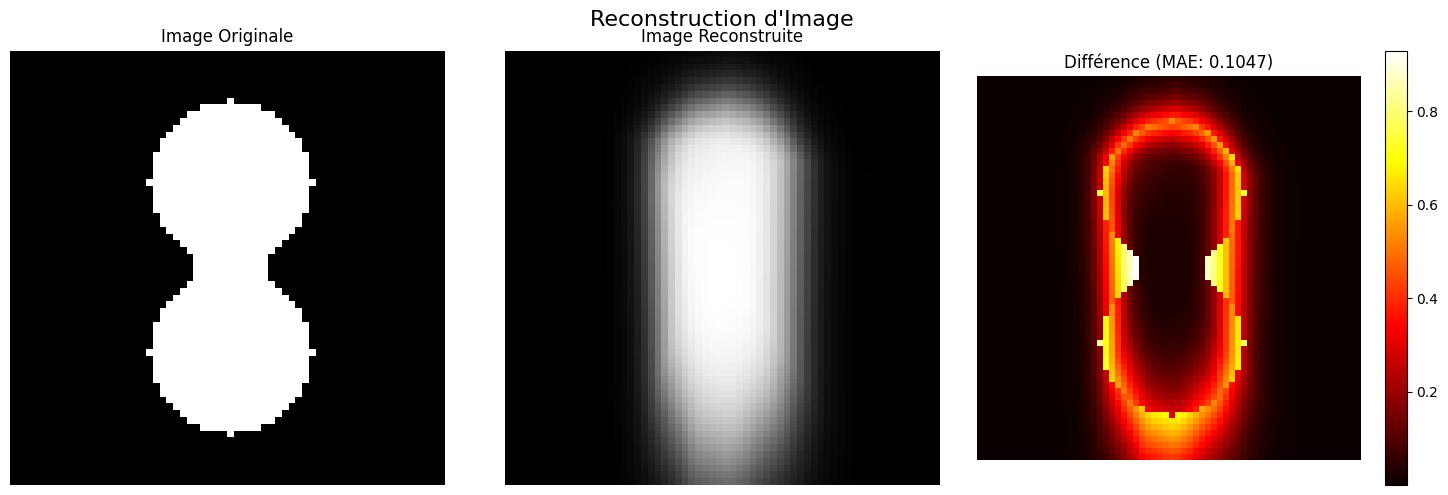

In [ ]:
class ReconstructionImage:
    """
    Reconstruction d'images avec des réseaux de neurones
    """

    def __init__(self):
        self.model = None
        self.img_shape = None
        self.img_original = None

    def creer_image_test(self, size=(64, 64), pattern='gradient'):
        h, w = size
        if pattern == 'gradient':
            x, y = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
            img = (x + y) / 2
        elif pattern == 'circle':
            x, y = np.meshgrid(np.linspace(-1, 1, w), np.linspace(-1, 1, h))
            img = 1 - np.sqrt(x**2 + y**2)
            img = np.clip(img, 0, 1)
        elif pattern == 'checkerboard':
            img = np.zeros((h, w))
            for i in range(0, h, 8):
                for j in range(0, w, 8):
                    if ((i // 8) + (j // 8)) % 2 == 0:
                        img[i:i+8, j:j+8] = 1
        elif pattern == 'random':
            img = np.random.rand(h, w)
        else:
            raise ValueError(f"Pattern '{pattern}' non reconnu")
        self.img_original = img.astype(np.float32)
        self.img_shape = size
        return img

    def creer_image_os_stylise(self, size=(64,64)):
        h, w = size
        img = np.zeros((h, w), dtype=np.float32)

        rr, cc = np.ogrid[:h, :w]
        center1 = (int(h*0.3), int(w*0.5))
        center2 = (int(h*0.7), int(w*0.5))
        radius = int(h*0.2)

        circle1 = (rr - center1[0])**2 + (cc - center1[1])**2 <= radius**2
        circle2 = (rr - center2[0])**2 + (cc - center2[1])**2 <= radius**2
        rect = (rr > center1[0]) & (rr < center2[0]) & (np.abs(cc - center1[1]) < radius//2)

        img[circle1 | circle2 | rect] = 1.0

        self.img_original = img
        self.img_shape = size
        return img

    def preparer_donnees(self, img):
        h, w = img.shape
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        X = np.stack([x.ravel(), y.ravel()], axis=1) / np.array([w-1, h-1])
        Y = img.ravel()[:, None]
        return X, Y

    def creer_modele(self, architecture='simple'):
        if architecture == 'simple':
            self.model = Sequential([
                Dense(64, activation='relu', input_shape=(2,)),
                Dense(64, activation='relu'),
                Dense(1, activation='sigmoid')
            ])
        elif architecture == 'deep':
            self.model = Sequential([
                Dense(128, activation='relu', input_shape=(2,)),
                Dense(128, activation='relu'),
                Dense(64, activation='relu'),
                Dense(32, activation='relu'),
                Dense(1, activation='sigmoid')
            ])
        elif architecture == 'wide':
            self.model = Sequential([
                Dense(256, activation='relu', input_shape=(2,)),
                Dense(256, activation='relu'),
                Dense(1, activation='sigmoid')
            ])
        else:
            raise ValueError(f"Architecture '{architecture}' non reconnue")
        self.model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return self.model

    def entrainer(self, X, Y, epochs=100, batch_size=512, verbose=1):
        if self.model is None:
            raise ValueError("Modèle non créé. Utilisez creer_modele() d'abord.")
        print(f"🎯 Entraînement du modèle...")
        print(f"   Échantillons: {len(X)}")
        print(f"   Epochs: {epochs}")
        print(f"   Batch size: {batch_size}")
        history = self.model.fit(X, Y, epochs=epochs, batch_size=batch_size,
                                 verbose=verbose, validation_split=0.1)
        return history

    def reconstruire(self, resolution=None):
        if self.model is None:
            raise ValueError("Modèle non entraîné")
        if resolution is None:
            resolution = self.img_shape
        h, w = resolution
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        X_grid = np.stack([x.ravel(), y.ravel()], axis=1) / np.array([w-1, h-1])
        Y_pred = self.model.predict(X_grid, verbose=0)
        img_reconstruit = Y_pred.reshape(h, w)
        return img_reconstruit

    def visualiser_resultats(self, img_reconstruit, titre="Reconstruction d'Image"):
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(self.img_original, cmap='gray')
        plt.title('Image Originale')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.imshow(img_reconstruit, cmap='gray')
        plt.title('Image Reconstruite')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        diff = np.abs(self.img_original - img_reconstruit)
        plt.imshow(diff, cmap='hot')
        plt.title(f'Différence (MAE: {np.mean(diff):.4f})')
        plt.axis('off')
        plt.colorbar()
        plt.suptitle(titre, fontsize=16)
        plt.tight_layout()
        plt.show()

# --- Exemple d'utilisation complet ---

ri = ReconstructionImage()

# Générer une image stylisée en forme d'os
img_test = ri.creer_image_os_stylise(size=(64,64))

# Préparer les données
X, Y = ri.preparer_donnees(img_test)

# Créer et compiler le modèle
ri.creer_modele(architecture='simple')

# Entraîner le modèle
ri.entrainer(X, Y, epochs=100, batch_size=512, verbose=2)

# Reconstruire l'image
img_reconstruit = ri.reconstruire()

# Visualiser les résultats
ri.visualiser_resultats(img_reconstruit)




<br><br>


<h1 style="color:blue; font-size:32px;">
CHAPITRE 5: RÉSEAUX CONVOLUTIFS (CNN)
</h1>


Analyse et visualisation des réseaux de neurones convolutifs
    
    Théorie:
    Les CNN utilisent:
    1. Convolution: Détection de motifs locaux
    2. Pooling: Réduction de dimensionnalité
    3. Filtres: Apprentissage automatique de caractéristiques

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


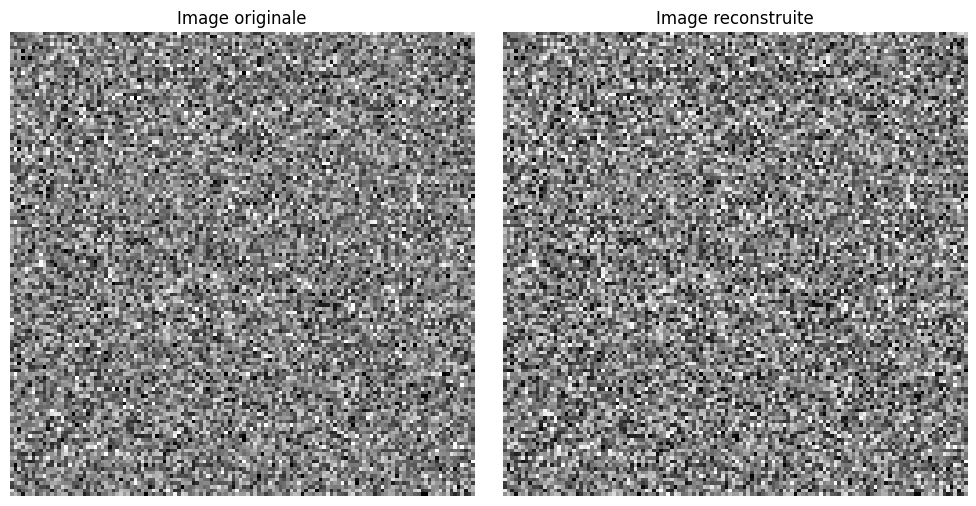

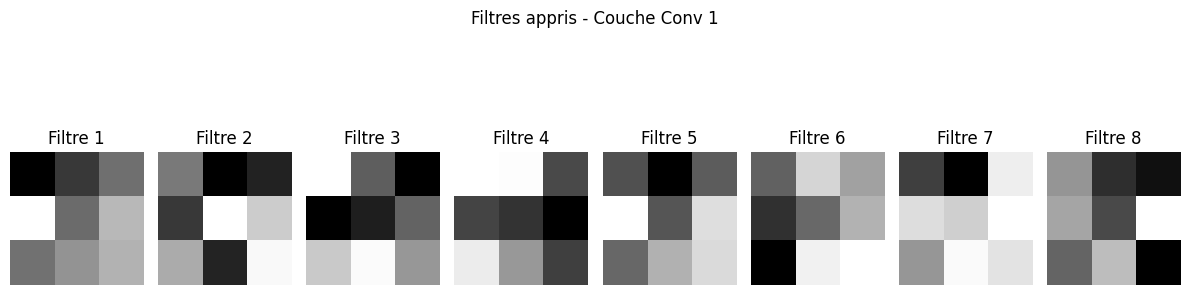

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


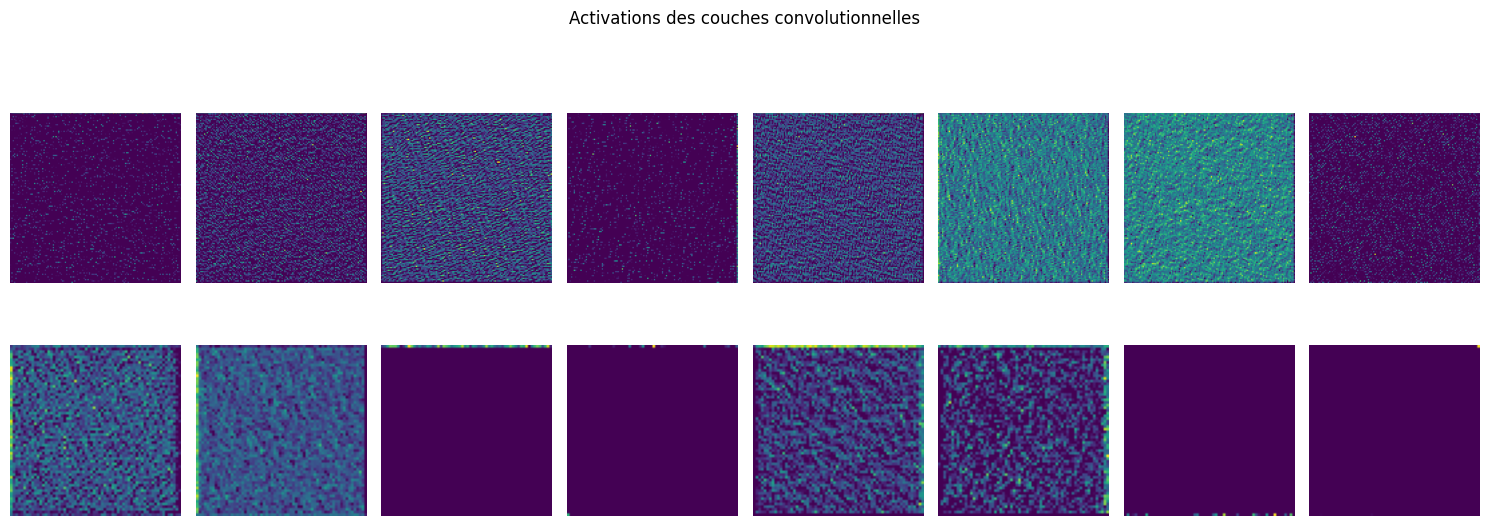

In [ ]:

# 1. Image aléatoire
img_np = np.clip(np.random.normal(loc=0.5, scale=0.2, size=(128, 128)), 0, 1).astype(np.float32)

# 2. Définition du modèle CNN avec API fonctionnelle
input_layer = Input(shape=(128*128,))
x = Reshape((128, 128, 1))(input_layer)
x = Conv2D(32, kernel_size=3, padding='same', activation='relu', name='conv1')(x)
x = MaxPooling2D(pool_size=2)(x)
x = Conv2D(64, kernel_size=3, padding='same', activation='relu', name='conv2')(x)
x = MaxPooling2D(pool_size=2)(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
output_layer = Dense(128*128, activation='sigmoid')(x)

model_cnn = Model(inputs=input_layer, outputs=output_layer)

# 3. Compilation et entraînement
model_cnn.compile(optimizer='adam', loss='mse')
model_cnn.fit(img_np.reshape(1, 128*128), img_np.reshape(1, 128*128), epochs=30, verbose=0)

# 4. Reconstruction
img_pred = model_cnn.predict(img_np.reshape(1, 128*128))[0].reshape(128, 128)

# 5. Affichage original vs reconstruit
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Image originale')
plt.imshow(img_np, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Image reconstruite')
plt.imshow(img_pred, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# 6. Filtres de la première couche convolutionnelle
filters, biases = model_cnn.get_layer('conv1').get_weights()
n_filters = filters.shape[-1]

plt.figure(figsize=(12, 4))
for i in range(min(n_filters, 8)):
    plt.subplot(1, 8, i + 1)
    plt.imshow(filters[:, :, 0, i], cmap='gray')
    plt.title(f'Filtre {i+1}')
    plt.axis('off')
plt.suptitle("Filtres appris - Couche Conv 1")
plt.tight_layout()
plt.show()

# 7. Visualisation des activations des couches convolutionnelles
activation_model = Model(inputs=model_cnn.input,
                         outputs=[model_cnn.get_layer('conv1').output, model_cnn.get_layer('conv2').output])

activations = activation_model.predict(img_np.reshape(1, 128*128))

plt.figure(figsize=(15, 6))
for i, activation in enumerate(activations):
    n_features = activation.shape[-1]
    for j in range(min(n_features, 8)):
        plt.subplot(len(activations), 8, i * 8 + j + 1)
        plt.imshow(activation[0, :, :, j], cmap='viridis')
        plt.axis('off')
plt.suptitle("Activations des couches convolutionnelles")
plt.tight_layout()
plt.show()